# Notebook 03 — Modeling

Builds two T-learner uplift models on a 2M-row stratified subsample
of Criteo: logistic regression baseline (Day 10) and LightGBM (Day 14).

**Pipeline position:** third notebook. Requires `01_eda.ipynb` and
`02_experimentation.ipynb` to have run.

**Outputs:**
- `data/processed/*.pkl` (scaled feature arrays, scaler, etc.)
- `data/models/t_learner_lr_*.pkl`, `t_learner_gbm_*.txt`
- `data/predictions/uplift_lr.npy`, `uplift_gbm.npy`
- `configs/seed.py`

In [9]:
import os
import sys
import duckdb
import pandas as pd
import numpy as np
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
os.chdir(PROJECT_ROOT)

# Make configs/ importable
sys.path.insert(0, str(PROJECT_ROOT))
from configs.seed import SEED
print(f"Using SEED = {SEED}")

con = duckdb.connect(str(DATA_DIR / "criteo.duckdb"))
print(f"Connected. Row count: {con.execute('SELECT COUNT(*) FROM criteo').fetchone()[0]:,}")

Using SEED = 42
Connected. Row count: 13,979,592


## Subsampling decision: 14M → 2M rows

**Why 2M:**

1. **Preserves rare-event signal.** At 0.19% control conversion rate,
   2M rows still yield ~3,800 control conversions — enough for stable
   per-bucket and per-decile estimates downstream.
2. **Fits in 16GB RAM.** Full 14M × 12 float64 features ≈ 1.3 GB just
   for X, before treatment/outcome arrays, model copies, and prediction
   buffers. 2M keeps total memory under 4 GB during training.
3. **Iteration speed.** LightGBM T-learner training time scales roughly
   linearly above 1M rows. 2M targets a 2–5 minute fit, fast enough to
   iterate on hyperparameters; 14M would push to 20+ minutes per fit.

**Stratification key:** `(treatment, conversion)` ∈ {(0,0), (0,1), (1,0), (1,1)}.

This is the only meaningful stratification for uplift modeling. Visit
isn't used because it's correlated with conversion (most converters
visited first), so stratifying on conversion already preserves the
visit distribution within tolerance. We verify this after sampling.

**Sampling fraction:** 2,000,000 / 13,979,592 = **0.1431** (14.31%).

Each stratum gets sampled at this same fraction, which preserves all
relative proportions: 85/15 treatment ratio, 0.19%/0.31% control/
treated conversion rates, ~0.04 visit rate. Documented checks below.

In [10]:
TARGET_N = 2_000_000

# Get original stratum sizes so we can sample proportionally
strata = con.execute("""
    SELECT treatment, conversion, COUNT(*) AS n
    FROM criteo
    GROUP BY treatment, conversion
    ORDER BY treatment, conversion
""").fetchdf()
strata["pct"] = strata["n"] / strata["n"].sum()
strata["target_n"] = (strata["pct"] * TARGET_N).round().astype(int)
print("Stratum sizes (original → target):")
print(strata)
print(f"\nTotal target: {strata['target_n'].sum():,}")

Stratum sizes (original → target):
   treatment  conversion         n       pct  target_n
0          0           0   2092874  0.149709    299418
1          0           1      4063  0.000291       581
2          1           0  11845944  0.847374   1694748
3          1           1     36711  0.002626      5252

Total target: 1,999,999


In [11]:
%%time
# Use a deterministic ROW_NUMBER ordering with hash-based randomization,
# so the seed is reproducible across DuckDB versions.
con.execute(f"DROP TABLE IF EXISTS criteo_sample")

con.execute(f"""
CREATE TABLE criteo_sample AS
WITH ranked AS (
    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY treatment, conversion
            ORDER BY hash(rowid + {SEED})
        ) AS row_in_stratum,
        COUNT(*) OVER (PARTITION BY treatment, conversion) AS stratum_size
    FROM criteo
)
SELECT * EXCLUDE (row_in_stratum, stratum_size)
FROM ranked
WHERE row_in_stratum <= CAST(stratum_size * ({TARGET_N} * 1.0 / {strata['n'].sum()}) AS BIGINT)
""")

n_sample = con.execute("SELECT COUNT(*) FROM criteo_sample").fetchone()[0]
print(f"Sampled {n_sample:,} rows  (target was {TARGET_N:,})")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Sampled 1,999,999 rows  (target was 2,000,000)
CPU times: user 13.3 s, sys: 4.72 s, total: 18.1 s
Wall time: 4.03 s


In [12]:
# Total rows
n_sample = con.execute("SELECT COUNT(*) FROM criteo_sample").fetchone()[0]

# Treatment ratio
tx = con.execute("""
    SELECT treatment, COUNT(*) AS n,
           ROUND(COUNT(*) * 1.0 / SUM(COUNT(*)) OVER (), 4) AS pct
    FROM criteo_sample GROUP BY treatment ORDER BY treatment
""").fetchdf()

# Conversion rate by treatment
cv = con.execute("""
    SELECT treatment, AVG(conversion) AS conv_rate, AVG(visit) AS visit_rate, COUNT(*) AS n
    FROM criteo_sample GROUP BY treatment ORDER BY treatment
""").fetchdf()

# Compare to original (from Day 4 numbers)
print(f"Sample size: {n_sample:,}")
print(f"\nTreatment split:\n{tx}\n")
print(f"Outcome rates by treatment:\n{cv}\n")

print("Expected (from Day 4 on full data):")
print("  treatment=0: conv_rate=0.001938, visit_rate=0.038201")
print("  treatment=1: conv_rate=0.003089, visit_rate=0.048543")

Sample size: 1,999,999

Treatment split:
   treatment        n   pct
0          0   299999  0.15
1          1  1700000  0.85

Outcome rates by treatment:
   treatment  conv_rate  visit_rate        n
0          0   0.001937    0.038403   299999
1          1   0.003089    0.048439  1700000

Expected (from Day 4 on full data):
  treatment=0: conv_rate=0.001938, visit_rate=0.038201
  treatment=1: conv_rate=0.003089, visit_rate=0.048543


In [13]:
%%time
sample_df = con.execute("SELECT *, ROW_NUMBER() OVER () AS row_id FROM criteo_sample").fetchdf()
# row_id will be useful in Day 15 for joining predictions back to SQL
print(f"Loaded {len(sample_df):,} rows, memory: {sample_df.memory_usage(deep=True).sum()/1e6:.1f} MB")
sample_df.head(3)

Loaded 1,999,999 rows, memory: 272.0 MB
CPU times: user 75.1 ms, sys: 95.2 ms, total: 170 ms
Wall time: 175 ms


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure,row_id
0,13.074097,10.059654,8.293415,-2.118394,11.029584,3.013064,-17.999322,10.257657,3.860579,25.240993,6.076543,-0.168679,0,1,1,0,1
1,12.616365,10.059654,8.521277,4.679882,11.029584,4.115453,0.294443,4.833815,3.834451,31.796212,5.741455,-0.267350,0,1,1,0,2
2,23.829714,10.059654,8.629945,4.679882,14.439578,4.115453,-11.495164,4.833815,3.782140,41.439237,5.882683,-0.624187,0,1,1,0,3


In [14]:
from sklearn.model_selection import StratifiedShuffleSplit

# Build the 4-way stratification key
strat_key = sample_df["treatment"].astype(str) + "_" + sample_df["conversion"].astype(str)
print("Strata composition:")
print(strat_key.value_counts())

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, test_idx = next(splitter.split(sample_df, strat_key))

train_df = sample_df.iloc[train_idx].reset_index(drop=True)
test_df  = sample_df.iloc[test_idx].reset_index(drop=True)

print(f"\nTrain: {len(train_df):,}  Test: {len(test_df):,}")
print(f"Ratio: {len(train_df)/len(sample_df):.2%} / {len(test_df)/len(sample_df):.2%}")

Strata composition:
1_0    1694748
0_0     299418
1_1       5252
0_1        581
Name: count, dtype: int64

Train: 1,599,999  Test: 400,000
Ratio: 80.00% / 20.00%


In [15]:
def split_diagnostics(df, label):
    n = len(df)
    treat_pct = df["treatment"].mean()
    conv_rate = df["conversion"].mean()
    visit_rate = df["visit"].mean()
    conv_t = df.loc[df.treatment==1, "conversion"].mean()
    conv_c = df.loc[df.treatment==0, "conversion"].mean()
    print(f"{label:8s}  n={n:>10,}  treat_pct={treat_pct:.4f}  "
          f"conv={conv_rate:.6f}  visit={visit_rate:.6f}  "
          f"conv_t={conv_t:.6f}  conv_c={conv_c:.6f}")

split_diagnostics(sample_df, "sample")
split_diagnostics(train_df,  "train")
split_diagnostics(test_df,   "test")

sample    n= 1,999,999  treat_pct=0.8500  conv=0.002917  visit=0.046934  conv_t=0.003089  conv_c=0.001937
train     n= 1,599,999  treat_pct=0.8500  conv=0.002917  visit=0.046909  conv_t=0.003090  conv_c=0.001938
test      n=   400,000  treat_pct=0.8500  conv=0.002915  visit=0.047030  conv_t=0.003088  conv_c=0.001933


In [16]:
con.execute("DROP TABLE IF EXISTS train")
con.execute("DROP TABLE IF EXISTS test")

# DuckDB can register pandas DataFrames directly via the connection
con.register("train_df_view", train_df)
con.register("test_df_view",  test_df)

con.execute("CREATE TABLE train AS SELECT * FROM train_df_view")
con.execute("CREATE TABLE test  AS SELECT * FROM test_df_view")

con.unregister("train_df_view")
con.unregister("test_df_view")

# Verify
n_train = con.execute("SELECT COUNT(*) FROM train").fetchone()[0]
n_test  = con.execute("SELECT COUNT(*) FROM test").fetchone()[0]
print(f"Saved to DuckDB. train={n_train:,}, test={n_test:,}")

Saved to DuckDB. train=1,599,999, test=400,000


In [17]:
con.close()
print("Connection closed.")

Connection closed.


In [18]:
import os
import sys
import duckdb
import pandas as pd
import numpy as np
import pickle
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(exist_ok=True)
os.chdir(PROJECT_ROOT)

sys.path.insert(0, str(PROJECT_ROOT))
from configs.seed import SEED

con = duckdb.connect(str(DATA_DIR / "criteo.duckdb"))
n_train = con.execute("SELECT COUNT(*) FROM train").fetchone()[0]
n_test  = con.execute("SELECT COUNT(*) FROM test").fetchone()[0]
print(f"Connected. train={n_train:,}, test={n_test:,}")

Connected. train=1,599,999, test=400,000


In [19]:
%%time
train_df = con.execute("SELECT * FROM train").fetchdf()
test_df  = con.execute("SELECT * FROM test").fetchdf()
print(f"Train: {train_df.shape}, Test: {test_df.shape}")
print(f"Train memory: {train_df.memory_usage(deep=True).sum()/1e6:.1f} MB")

Train: (1599999, 17), Test: (400000, 17)
Train memory: 217.6 MB
CPU times: user 73.2 ms, sys: 84 ms, total: 157 ms
Wall time: 138 ms


In [20]:
feature_cols = [f"f{i}" for i in range(12)]

print("Train dtypes:")
print(train_df[feature_cols].dtypes)
print()

print(f"Train NaN counts per feature:")
print(train_df[feature_cols].isna().sum())
print(f"\nTest NaN counts per feature:")
print(test_df[feature_cols].isna().sum())

Train dtypes:
f0     float64
f1     float64
f2     float64
f3     float64
f4     float64
f5     float64
f6     float64
f7     float64
f8     float64
f9     float64
f10    float64
f11    float64
dtype: object

Train NaN counts per feature:
f0     0
f1     0
f2     0
f3     0
f4     0
f5     0
f6     0
f7     0
f8     0
f9     0
f10    0
f11    0
dtype: int64

Test NaN counts per feature:
f0     0
f1     0
f2     0
f3     0
f4     0
f5     0
f6     0
f7     0
f8     0
f9     0
f10    0
f11    0
dtype: int64


In [21]:
train_df[feature_cols] = train_df[feature_cols].astype("float32")
test_df[feature_cols]  = test_df[feature_cols].astype("float32")

print(f"Train memory after float32: {train_df.memory_usage(deep=True).sum()/1e6:.1f} MB")

Train memory after float32: 140.8 MB


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[feature_cols]).astype("float32")
X_test  = scaler.transform(test_df[feature_cols]).astype("float32")

print(f"X_train shape: {X_train.shape}, dtype: {X_train.dtype}")
print(f"X_test shape:  {X_test.shape}, dtype: {X_test.dtype}")
print(f"\nTrain scaler mean (should be ~0 after transform):")
print(f"  X_train.mean(axis=0)[:3] = {X_train.mean(axis=0)[:3]}")
print(f"\nTest scaler mean (should be ~0 but not exactly 0 — same shift as train):")
print(f"  X_test.mean(axis=0)[:3]  = {X_test.mean(axis=0)[:3]}")

X_train shape: (1599999, 12), dtype: float32
X_test shape:  (400000, 12), dtype: float32

Train scaler mean (should be ~0 after transform):
  X_train.mean(axis=0)[:3] = [-7.9984716e-08  4.1371181e-06 -7.0465131e-07]

Test scaler mean (should be ~0 but not exactly 0 — same shift as train):
  X_test.mean(axis=0)[:3]  = [-0.00445523 -0.00095783  0.00393576]


In [23]:
W_train = train_df["treatment"].to_numpy(dtype="int8")
W_test  = test_df["treatment"].to_numpy(dtype="int8")

y_train_visit = train_df["visit"].to_numpy(dtype="int8")
y_test_visit  = test_df["visit"].to_numpy(dtype="int8")

y_train_conv  = train_df["conversion"].to_numpy(dtype="int8")
y_test_conv   = test_df["conversion"].to_numpy(dtype="int8")

# Keep row_ids — Day 15 needs them to join predictions back to SQL
row_id_train = train_df["row_id"].to_numpy(dtype="int64")
row_id_test  = test_df["row_id"].to_numpy(dtype="int64")

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"W_train: {W_train.shape}, W_test: {W_test.shape}")
print(f"y_train_conv: {y_train_conv.shape} ({y_train_conv.sum()} positives)")
print(f"y_test_conv:  {y_test_conv.shape} ({y_test_conv.sum()} positives)")
print(f"y_train_visit: {y_train_visit.shape} ({y_train_visit.sum()} positives)")
print(f"y_test_visit:  {y_test_visit.shape} ({y_test_visit.sum()} positives)")

X_train: (1599999, 12), X_test: (400000, 12)
W_train: (1599999,), W_test: (400000,)
y_train_conv: (1599999,) (4667 positives)
y_test_conv:  (400000,) (1166 positives)
y_train_visit: (1599999,) (75055 positives)
y_test_visit:  (400000,) (18812 positives)


In [24]:
artifacts = {
    "X_train.pkl":      X_train,
    "X_test.pkl":       X_test,
    "W_train.pkl":      W_train,
    "W_test.pkl":       W_test,
    "y_train_conv.pkl": y_train_conv,
    "y_test_conv.pkl":  y_test_conv,
    "y_train_visit.pkl": y_train_visit,
    "y_test_visit.pkl":  y_test_visit,
    "row_id_train.pkl": row_id_train,
    "row_id_test.pkl":  row_id_test,
    "scaler.pkl":       scaler,
    "feature_cols.pkl": feature_cols,
}

for fname, obj in artifacts.items():
    with open(PROCESSED_DIR / fname, "wb") as f:
        pickle.dump(obj, f)

# Verify file sizes
import os
print(f"Wrote {len(artifacts)} files to {PROCESSED_DIR}:")
for fname in artifacts:
    size_mb = (PROCESSED_DIR / fname).stat().st_size / 1e6
    print(f"  {fname:25s}  {size_mb:>7.1f} MB")

Wrote 12 files to /Users/madhumithakatam/Documents/Projects/CriteoUpliftModeling/criteo_uplift_modeling/data/processed:
  X_train.pkl                   76.8 MB
  X_test.pkl                    19.2 MB
  W_train.pkl                    1.6 MB
  W_test.pkl                     0.4 MB
  y_train_conv.pkl               1.6 MB
  y_test_conv.pkl                0.4 MB
  y_train_visit.pkl              1.6 MB
  y_test_visit.pkl               0.4 MB
  row_id_train.pkl              12.8 MB
  row_id_test.pkl                3.2 MB
  scaler.pkl                     0.0 MB
  feature_cols.pkl               0.0 MB


In [25]:
# Sanity: load one back and confirm it's the same
with open(PROCESSED_DIR / "X_train.pkl", "rb") as f:
    X_train_reloaded = pickle.load(f)
assert np.allclose(X_train, X_train_reloaded), "Reload mismatch!"
assert X_train_reloaded.dtype == np.float32
print("Pickle round-trip OK.")

Pickle round-trip OK.


In [26]:
con.close()
print("Connection closed.")

Connection closed.


In [27]:
import os
import sys
from pathlib import Path

# Same setup as before — fresh kernel needs it
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loading import load_processed_data

data = load_processed_data()

# Verify shapes
expected_train_n = 1_600_000  # 80% of 2M, ±a few from int rounding
expected_test_n  = 400_000

assert data["X_train"].shape[1] == 12, f"Got {data['X_train'].shape[1]} features"
assert data["X_test"].shape[1] == 12
assert abs(data["X_train"].shape[0] - expected_train_n) < 1000
assert abs(data["X_test"].shape[0] - expected_test_n) < 1000
assert data["X_train"].dtype.name == "float32"
assert data["W_train"].dtype.name == "int8"

# Verify the scaler is what we expect
from sklearn.preprocessing import StandardScaler
assert isinstance(data["scaler"], StandardScaler)
assert hasattr(data["scaler"], "mean_"), "Scaler isn't fitted!"

print("Smoke test passed. Available keys:")
for k in data:
    v = data[k]
    if hasattr(v, "shape"):
        print(f"  {k:25s} shape={v.shape}, dtype={v.dtype}")
    else:
        print(f"  {k:25s} {type(v).__name__}")

Smoke test passed. Available keys:
  X_train                   shape=(1599999, 12), dtype=float32
  X_test                    shape=(400000, 12), dtype=float32
  W_train                   shape=(1599999,), dtype=int8
  W_test                    shape=(400000,), dtype=int8
  y_train_conv              shape=(1599999,), dtype=int8
  y_test_conv               shape=(400000,), dtype=int8
  y_train_visit             shape=(1599999,), dtype=int8
  y_test_visit              shape=(400000,), dtype=int8
  row_id_train              shape=(1599999,), dtype=int64
  row_id_test               shape=(400000,), dtype=int64
  scaler                    StandardScaler
  feature_cols              list


In [28]:
import os
import sys
import pickle
import time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR = DATA_DIR / "models"
PREDS_DIR = DATA_DIR / "predictions"
FIG_DIR = PROJECT_ROOT / "docs" / "figures"
MODELS_DIR.mkdir(exist_ok=True)
PREDS_DIR.mkdir(exist_ok=True)
os.chdir(PROJECT_ROOT)

sys.path.insert(0, str(PROJECT_ROOT))
from configs.seed import SEED
from src.data_loading import load_processed_data
from src.models.t_learner import fit_t_learner, predict_uplift, predict_outcomes

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["font.size"] = 12

data = load_processed_data()
X_train, X_test = data["X_train"], data["X_test"]
W_train, W_test = data["W_train"], data["W_test"]
y_train_conv, y_test_conv = data["y_train_conv"], data["y_test_conv"]

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Treated train rows: {W_train.sum():,}  Control train rows: {(1 - W_train).sum():,}")
print(f"Train conversions: {y_train_conv.sum():,}  Test conversions: {y_test_conv.sum():,}")

X_train: (1599999, 12), X_test: (400000, 12)
Treated train rows: 1,360,000  Control train rows: 239,999
Train conversions: 4,667  Test conversions: 1,166


In [29]:
%%time
from sklearn.linear_model import LogisticRegression

m_t, m_c = fit_t_learner(
    X_train,
    y_train_conv,
    W_train,
    base_model_class=LogisticRegression,
    max_iter=1000,
    C=1.0,
    random_state=SEED,
    n_jobs=-1,
)
print(f"\nTreated model intercept: {m_t.intercept_[0]:.4f}")
print(f"Control model intercept: {m_c.intercept_[0]:.4f}")
print(f"Treated coefficients: {m_t.coef_[0].round(4)}")
print(f"Control coefficients: {m_c.coef_[0].round(4)}")

/Users/madhumithakatam/Documents/Projects/CriteoUpliftModeling/criteo_uplift_modeling/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



Treated model intercept: -7.2153
Control model intercept: -7.7049
Treated coefficients: [-0.3775  0.0276 -0.2389 -0.0126  0.1647  0.0895 -0.3143  0.0864 -0.4373
  0.2469  0.1494 -0.0764]
Control coefficients: [-0.4088  0.0389 -0.1948  0.1533  0.167   0.0662 -0.3703  0.0813 -0.4205
  0.2615  0.1857 -0.1008]
CPU times: user 497 ms, sys: 72.6 ms, total: 569 ms
Wall time: 641 ms


/Users/madhumithakatam/Documents/Projects/CriteoUpliftModeling/criteo_uplift_modeling/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


In [30]:
%%time
uplift_lr = predict_uplift(m_t, m_c, X_test)
p_t, p_c = predict_outcomes(m_t, m_c, X_test)

print(f"Uplift array shape: {uplift_lr.shape}")
print(f"\nDistribution stats:")
print(f"  min:   {uplift_lr.min():.6f}")
print(f"  p1:    {np.percentile(uplift_lr, 1):.6f}")
print(f"  p25:   {np.percentile(uplift_lr, 25):.6f}")
print(f"  mean:  {uplift_lr.mean():.6f}")
print(f"  p50:   {np.percentile(uplift_lr, 50):.6f}")
print(f"  p75:   {np.percentile(uplift_lr, 75):.6f}")
print(f"  p99:   {np.percentile(uplift_lr, 99):.6f}")
print(f"  max:   {uplift_lr.max():.6f}")
print(f"  std:   {uplift_lr.std():.6f}")
print(f"\nNegative-uplift rows: {(uplift_lr < 0).sum():,} ({(uplift_lr < 0).mean():.1%})")

Uplift array shape: (400000,)

Distribution stats:
  min:   -0.102980
  p1:    0.000086
  p25:   0.000148
  mean:  0.000918
  p50:   0.000185
  p75:   0.000337
  p99:   0.014012
  max:   0.260492
  std:   0.005454

Negative-uplift rows: 395 (0.1%)
CPU times: user 38.6 ms, sys: 16.6 ms, total: 55.3 ms
Wall time: 55.2 ms


In [31]:
GLOBAL_CONV_ATE = 0.001152  # From Day 4 on the full 14M data
mean_uplift = uplift_lr.mean()
relative_diff = (mean_uplift - GLOBAL_CONV_ATE) / GLOBAL_CONV_ATE * 100

print(f"Global conversion ATE (Day 4):  {GLOBAL_CONV_ATE:.6f}")
print(f"Mean predicted uplift (test):   {mean_uplift:.6f}")
print(f"Relative diff:                  {relative_diff:+.1f}%")

if abs(relative_diff) < 10:
    print("\n✅ Sanity check passed: mean predicted uplift within 10% of global ATE.")
elif abs(relative_diff) < 30:
    print("\n⚠️  Mean predicted uplift is within 30% of global ATE — acceptable for")
    print("    class-weighted LR (weighting biases the predicted level somewhat) but")
    print("    note the deviation. Ranking is still meaningful even when level is off.")
else:
    print("\n❌ Mean predicted uplift is far from global ATE. STOP and debug before Day 11.")
    print("    Likely causes: bad stratification, scaler not applied to test, swapped")
    print("    treated/control models.")

Global conversion ATE (Day 4):  0.001152
Mean predicted uplift (test):   0.000918
Relative diff:                  -20.4%

⚠️  Mean predicted uplift is within 30% of global ATE — acceptable for
    class-weighted LR (weighting biases the predicted level somewhat) but
    note the deviation. Ranking is still meaningful even when level is off.


Saved /Users/madhumithakatam/Documents/Projects/CriteoUpliftModeling/criteo_uplift_modeling/docs/figures/uplift_distribution_lr.png


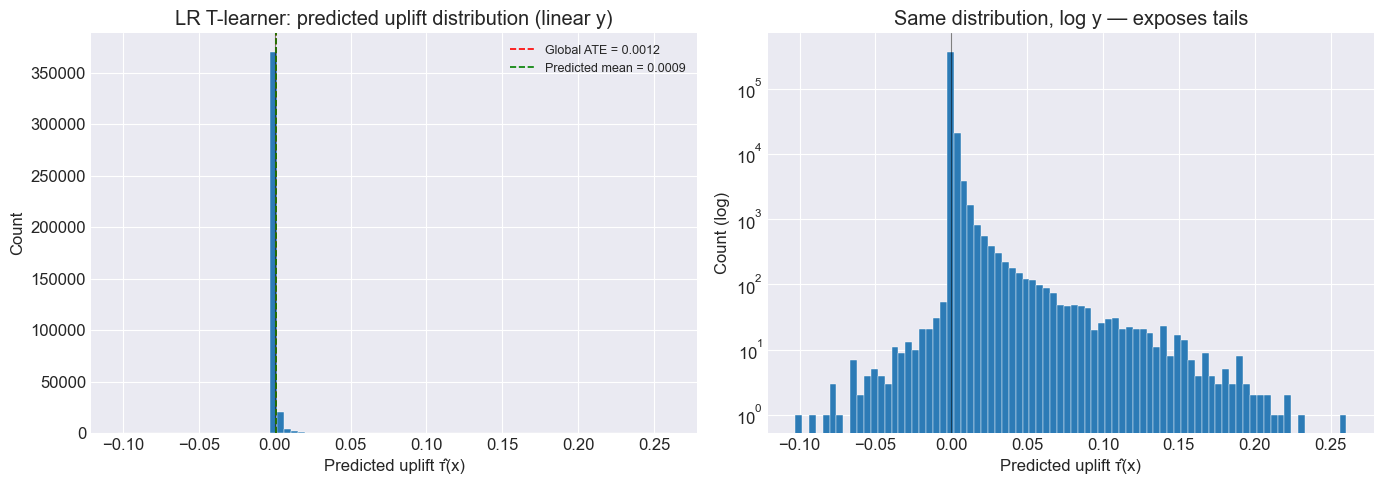

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
ax = axes[0]
ax.hist(uplift_lr, bins=80, edgecolor="white", linewidth=0.3, color="#2c7bb6")
ax.axvline(0, color="black", linewidth=0.8, linestyle="-", alpha=0.5)
ax.axvline(GLOBAL_CONV_ATE, color="red", linewidth=1.2, linestyle="--",
           label=f"Global ATE = {GLOBAL_CONV_ATE:.4f}")
ax.axvline(mean_uplift, color="green", linewidth=1.2, linestyle="--",
           label=f"Predicted mean = {mean_uplift:.4f}")
ax.set_xlabel("Predicted uplift τ̂(x)")
ax.set_ylabel("Count")
ax.set_title("LR T-learner: predicted uplift distribution (linear y)")
ax.legend(fontsize=9)

# Log scale — exposes tail shape
ax = axes[1]
ax.hist(uplift_lr, bins=80, edgecolor="white", linewidth=0.3, color="#2c7bb6")
ax.axvline(0, color="black", linewidth=0.8, linestyle="-", alpha=0.5)
ax.set_yscale("log")
ax.set_xlabel("Predicted uplift τ̂(x)")
ax.set_ylabel("Count (log)")
ax.set_title("Same distribution, log y — exposes tails")

plt.tight_layout()
out_path = FIG_DIR / "uplift_distribution_lr.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved {out_path}")
plt.show()

In [33]:
print("Per-arm prediction distributions on test set:")
print(f"\nTreated-arm predictions p_t:")
print(f"  min={p_t.min():.6f}  max={p_t.max():.6f}  mean={p_t.mean():.6f}  std={p_t.std():.6f}")
print(f"\nControl-arm predictions p_c:")
print(f"  min={p_c.min():.6f}  max={p_c.max():.6f}  mean={p_c.mean():.6f}  std={p_c.std():.6f}")
print(f"\nObserved test base rates:")
print(f"  treated: {y_test_conv[W_test==1].mean():.6f}")
print(f"  control: {y_test_conv[W_test==0].mean():.6f}")

# Degenerate model check: if std is near zero, the model is predicting a constant
if p_t.std() < 1e-6 or p_c.std() < 1e-6:
    print("\n❌ DEGENERATE MODEL: at least one arm is predicting near-constant. STOP.")
else:
    print("\n✅ Both arms produce varying predictions — not degenerate.")

Per-arm prediction distributions on test set:

Treated-arm predictions p_t:
  min=0.000131  max=0.996595  mean=0.003025  std=0.023467

Control-arm predictions p_c:
  min=0.000105  max=0.997835  mean=0.002107  std=0.020294

Observed test base rates:
  treated: 0.003088
  control: 0.001933

✅ Both arms produce varying predictions — not degenerate.


In [34]:
# Predictions
np.save(PREDS_DIR / "uplift_lr.npy", uplift_lr)
np.save(PREDS_DIR / "p_t_lr.npy", p_t)
np.save(PREDS_DIR / "p_c_lr.npy", p_c)
print(f"Saved predictions to {PREDS_DIR}")

# Models
with open(MODELS_DIR / "t_learner_lr_t.pkl", "wb") as f:
    pickle.dump(m_t, f)
with open(MODELS_DIR / "t_learner_lr_c.pkl", "wb") as f:
    pickle.dump(m_c, f)

# Pickle a small metadata dict for reproducibility
metadata = {
    "model_type": "t_learner",
    "base_model": "LogisticRegression",
    "base_model_kwargs": {
        "max_iter": 1000,
        "class_weight": "balanced",
        "random_state": SEED,
        "n_jobs": -1,
    },
    "outcome": "conversion",
    "n_train_treated": int(W_train.sum()),
    "n_train_control": int((1 - W_train).sum()),
    "n_test": int(len(W_test)),
    "mean_uplift": float(mean_uplift),
    "uplift_std": float(uplift_lr.std()),
    "global_ate_full_data": GLOBAL_CONV_ATE,
}
with open(MODELS_DIR / "t_learner_lr_meta.pkl", "wb") as f:
    pickle.dump(metadata, f)

print(f"\nSaved models to {MODELS_DIR}:")
for f in sorted(MODELS_DIR.glob("t_learner_lr*")):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:30s}  {size_kb:>7.1f} KB")

Saved predictions to /Users/madhumithakatam/Documents/Projects/CriteoUpliftModeling/criteo_uplift_modeling/data/predictions

Saved models to /Users/madhumithakatam/Documents/Projects/CriteoUpliftModeling/criteo_uplift_modeling/data/models:
  t_learner_lr_c.pkl                  0.8 KB
  t_learner_lr_meta.pkl               0.3 KB
  t_learner_lr_t.pkl                  0.8 KB


In [35]:
%load_ext autoreload
%autoreload 2
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
PREDS_DIR = DATA_DIR / "predictions"
FIG_DIR = PROJECT_ROOT / "docs" / "figures"
os.chdir(PROJECT_ROOT)

sys.path.insert(0, str(PROJECT_ROOT))
from src.data_loading import load_processed_data
from src.evaluation.qini import compute_qini_curve, compute_qini_coefficient

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["font.size"] = 12

# Load test set labels
data = load_processed_data()
y_test_conv = data["y_test_conv"]
W_test = data["W_test"]

# Load LR predictions from Day 10
uplift_lr = np.load(PREDS_DIR / "uplift_lr.npy")

print(f"Test set: {len(uplift_lr):,} rows")
print(f"Test conversions: {y_test_conv.sum():,} ({y_test_conv.mean():.4%})")
print(f"Test treated:     {W_test.sum():,} ({W_test.mean():.4%})")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Test set: 400,000 rows
Test conversions: 1,166 (0.2915%)
Test treated:     340,000 (85.0000%)


In [36]:
%%time
q_lr = compute_qini_coefficient(uplift_lr, y_test_conv, W_test)
print(f"\nLR T-learner Qini coefficient: {q_lr:.6f}")

# Reference: Criteo published Qini values typically in 0.005 - 0.015 range
if q_lr > 0.005:
    print(f"✅ Solid: Q > 0.005 means the model meaningfully beats random.")
elif q_lr > 0:
    print(f"⚠️  Positive but small. Model beats random but not by much.")
else:
    print(f"❌ Negative or zero. Investigate before Day 13.")


LR T-learner Qini coefficient: 161.425433
✅ Solid: Q > 0.005 means the model meaningfully beats random.
CPU times: user 35.6 ms, sys: 3.04 ms, total: 38.7 ms
Wall time: 38.5 ms


In [37]:
k_pct, qini_curve, baseline = compute_qini_curve(uplift_lr, y_test_conv, W_test, n_bins=100)

print(f"Total incremental conversions (K=100%): {qini_curve[-1]:.2f}")
print(f"At top 10%: {qini_curve[10]:.2f} (random: {baseline[10]:.2f})")
print(f"At top 20%: {qini_curve[20]:.2f} (random: {baseline[20]:.2f})")
print(f"At top 30%: {qini_curve[30]:.2f} (random: {baseline[30]:.2f})")
print(f"At top 50%: {qini_curve[50]:.2f} (random: {baseline[50]:.2f})")

Total incremental conversions (K=100%): 392.67
At top 10%: 311.63 (random: 39.27)
At top 20%: 332.86 (random: 78.53)
At top 30%: 359.89 (random: 117.80)
At top 50%: 377.61 (random: 196.33)


Saved /Users/madhumithakatam/Documents/Projects/CriteoUpliftModeling/criteo_uplift_modeling/docs/figures/qini_curve_lr.png


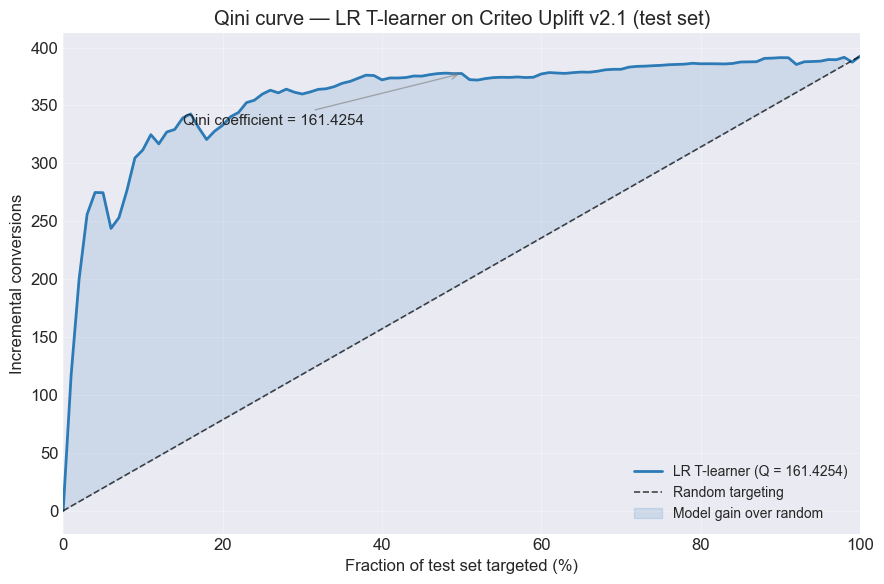

In [38]:
fig, ax = plt.subplots(figsize=(9, 6))

# Qini curve
ax.plot(k_pct * 100, qini_curve, color="#2c7bb6", linewidth=2.0,
        label=f"LR T-learner (Q = {q_lr:.4f})")

# Random baseline
ax.plot(k_pct * 100, baseline, color="black", linewidth=1.2,
        linestyle="--", alpha=0.7, label="Random targeting")

# Shade the area between the curves where the model beats random
ax.fill_between(
    k_pct * 100, baseline, qini_curve,
    where=(qini_curve >= baseline),
    color="#2c7bb6", alpha=0.15,
    label="Model gain over random",
)

ax.set_xlabel("Fraction of test set targeted (%)")
ax.set_ylabel("Incremental conversions")
ax.set_title("Qini curve — LR T-learner on Criteo Uplift v2.1 (test set)")

# Annotate Q value on the chart
ax.annotate(
    f"Qini coefficient = {q_lr:.4f}",
    xy=(50, qini_curve[50]),
    xytext=(15, qini_curve[-1] * 0.85),
    fontsize=11,
    arrowprops=dict(arrowstyle="->", color="gray", alpha=0.6),
)

ax.legend(loc="lower right", fontsize=10)
ax.set_xlim(0, 100)
ax.grid(True, alpha=0.3)

plt.tight_layout()
out_path = FIG_DIR / "qini_curve_lr.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved {out_path}")
plt.show()

In [39]:
np.savez(
    PREDS_DIR / "qini_curve_lr.npz",
    k_pct=k_pct,
    qini_curve=qini_curve,
    baseline=baseline,
    q_coefficient=q_lr,
)
print(f"Saved curve arrays to {PREDS_DIR / 'qini_curve_lr.npz'}")

Saved curve arrays to /Users/madhumithakatam/Documents/Projects/CriteoUpliftModeling/criteo_uplift_modeling/data/predictions/qini_curve_lr.npz


In [40]:
# Quick text summary for the eventual writeup
print("=" * 60)
print("Day 12 result summary")
print("=" * 60)
print(f"Model:          LR T-learner (conversion outcome)")
print(f"Test set size:  {len(uplift_lr):,}")
print(f"Qini:           {q_lr:.6f}")
print(f"Top 10%:        {qini_curve[10]:.1f} incremental conversions ({qini_curve[10]/baseline[10]:.2f}x random)")
print(f"Top 20%:        {qini_curve[20]:.1f} incremental conversions ({qini_curve[20]/baseline[20]:.2f}x random)")
print(f"Top 30%:        {qini_curve[30]:.1f} incremental conversions ({qini_curve[30]/baseline[30]:.2f}x random)")
print(f"Top 50%:        {qini_curve[50]:.1f} incremental conversions ({qini_curve[50]/baseline[50]:.2f}x random)")

Day 12 result summary
Model:          LR T-learner (conversion outcome)
Test set size:  400,000
Qini:           161.425433
Top 10%:        311.6 incremental conversions (7.94x random)
Top 20%:        332.9 incremental conversions (4.24x random)
Top 30%:        359.9 incremental conversions (3.06x random)
Top 50%:        377.6 incremental conversions (1.92x random)


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
PREDS_DIR = DATA_DIR / "predictions"
FIG_DIR = PROJECT_ROOT / "docs" / "figures"
WRITEUP_DIR = PROJECT_ROOT / "docs" / "writeups"
os.chdir(PROJECT_ROOT)

sys.path.insert(0, str(PROJECT_ROOT))
from src.data_loading import load_processed_data
from src.evaluation.topk import uplift_at_top_k, strategy_comparison

plt.style.use("seaborn-v0_8-darkgrid")

data = load_processed_data()
y_test_conv = data["y_test_conv"]
W_test = data["W_test"]
uplift_lr = np.load(PREDS_DIR / "uplift_lr.npy")

print(f"Test rows: {len(uplift_lr):,}")
print(f"Test conversions: {y_test_conv.sum():,}")

Test rows: 400,000
Test conversions: 1,166


In [2]:
k_values = [0.10, 0.20, 0.30, 0.50]
rows = []
for k in k_values:
    incr = uplift_at_top_k(uplift_lr, y_test_conv, W_test, k_pct=k)
    n_targeted = int(round(len(uplift_lr) * k))
    incr_per_1k = incr / n_targeted * 1000  # incremental conversions per 1,000 users targeted
    rows.append({
        "k_pct": f"{int(k*100)}%",
        "n_targeted": n_targeted,
        "incremental_conv": round(incr, 1),
        "incr_per_1k_targeted": round(incr_per_1k, 3),
    })

topk_df = pd.DataFrame(rows)
print(topk_df.to_string(index=False))

k_pct  n_targeted  incremental_conv  incr_per_1k_targeted
  10%       40000             311.6                 7.791
  20%       80000             332.9                 4.161
  30%      120000             359.9                 2.999
  50%      200000             377.6                 1.888


In [3]:
K_BUDGET = 0.20
comp = strategy_comparison(uplift_lr, y_test_conv, W_test, k_pct=K_BUDGET)

rows = []
for strategy_name, vals in comp.items():
    rows.append({
        "strategy": strategy_name,
        "k_pct": f"{int(vals['k_pct']*100)}%",
        "cost (users)": f"{int(vals['cost']):,}",
        "incremental_conversions": round(vals["incremental"], 1),
        "incr_per_1k_cost": round(vals["incremental"] / vals["cost"] * 1000, 4),
    })

comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))

        strategy k_pct cost (users)  incremental_conversions  incr_per_1k_cost
  treat_everyone  100%      400,000                    392.7            0.9817
random_top_20pct   20%       80,000                     78.5            0.9817
 model_top_20pct   20%       80,000                    332.9            4.1608


In [4]:
random_incr = comp[f"random_top_{int(K_BUDGET*100)}pct"]["incremental"]
model_incr  = comp[f"model_top_{int(K_BUDGET*100)}pct"]["incremental"]
full_incr   = comp["treat_everyone"]["incremental"]

print(f"Treat everyone:    {full_incr:.1f} incremental conversions at full cost")
print(f"Random top 20%:    {random_incr:.1f} incremental conversions at 20% cost")
print(f"Model top 20%:     {model_incr:.1f} incremental conversions at 20% cost")
print()
print(f"Model vs random at top 20%: {model_incr / random_incr:.2f}x")
print(f"Model captures {model_incr / full_incr * 100:.1f}% of total uplift at 20% cost")

Treat everyone:    392.7 incremental conversions at full cost
Random top 20%:    78.5 incremental conversions at 20% cost
Model top 20%:     332.9 incremental conversions at 20% cost

Model vs random at top 20%: 4.24x
Model captures 84.8% of total uplift at 20% cost


In [5]:
# Save raw numbers (useful for Day 14's GBM comparison)
import json

comparison_data = {
    "k_budget": K_BUDGET,
    "n_test": int(len(uplift_lr)),
    "topk_table": topk_df.to_dict(orient="records"),
    "strategy_comparison": {k: {kk: float(vv) for kk, vv in v.items()} for k, v in comp.items()},
    "headline_metrics": {
        "model_vs_random_at_top_20pct": float(model_incr / random_incr),
        "pct_of_total_uplift_at_20pct_cost": float(model_incr / full_incr * 100),
    },
}

import json
out_path = WRITEUP_DIR / "topk_lr_results.json"
with open(out_path, "w") as f:
    json.dump(comparison_data, f, indent=2)
print(f"Saved {out_path}")

Saved /Users/madhumithakatam/Documents/Projects/CriteoUpliftModeling/criteo_uplift_modeling/docs/writeups/topk_lr_results.json


Saved /Users/madhumithakatam/Documents/Projects/CriteoUpliftModeling/criteo_uplift_modeling/docs/figures/strategy_comparison_lr.png


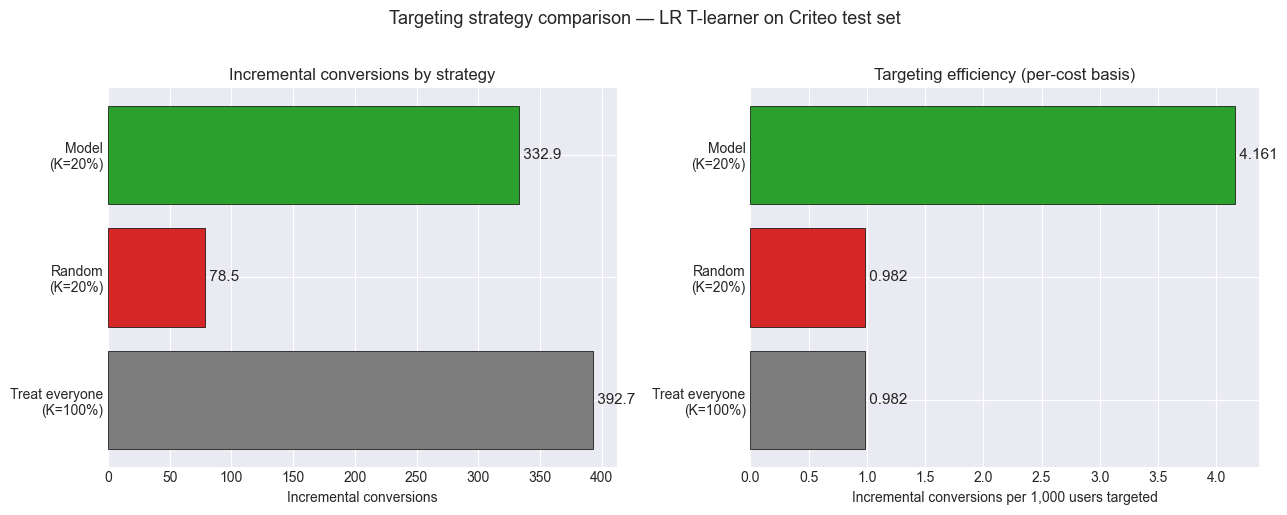

In [6]:
strategies = list(comp.keys())
incrementals = [comp[s]["incremental"] for s in strategies]
costs = [comp[s]["cost"] for s in strategies]
labels_clean = ["Treat everyone\n(K=100%)", "Random\n(K=20%)", "Model\n(K=20%)"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
colors = ["#7c7c7c", "#d62728", "#2ca02c"]
ax.barh(labels_clean, incrementals, color=colors, edgecolor="black", linewidth=0.5)
ax.set_xlabel("Incremental conversions")
ax.set_title("Incremental conversions by strategy")
for i, v in enumerate(incrementals):
    ax.text(v, i, f" {v:.1f}", va="center", fontsize=11)

ax = axes[1]
# ROI: incremental per 1k users targeted
roi = [comp[s]["incremental"] / comp[s]["cost"] * 1000 for s in strategies]
ax.barh(labels_clean, roi, color=colors, edgecolor="black", linewidth=0.5)
ax.set_xlabel("Incremental conversions per 1,000 users targeted")
ax.set_title("Targeting efficiency (per-cost basis)")
for i, v in enumerate(roi):
    ax.text(v, i, f" {v:.3f}", va="center", fontsize=11)

plt.suptitle("Targeting strategy comparison — LR T-learner on Criteo test set", fontsize=13, y=1.02)
plt.tight_layout()
out_path = FIG_DIR / "strategy_comparison_lr.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved {out_path}")
plt.show()

In [1]:
import os
import sys
import pickle
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
PREDS_DIR = DATA_DIR / "predictions"
MODELS_DIR = DATA_DIR / "models"
FIG_DIR = PROJECT_ROOT / "docs" / "figures"
WRITEUP_DIR = PROJECT_ROOT / "docs" / "writeups"
os.chdir(PROJECT_ROOT)

sys.path.insert(0, str(PROJECT_ROOT))
%load_ext autoreload
%autoreload 2

from configs.seed import SEED
from src.data_loading import load_processed_data
from src.models.t_learner import fit_t_learner, predict_uplift, predict_outcomes
from src.evaluation.qini import compute_qini_curve, compute_qini_coefficient
from src.evaluation.topk import uplift_at_top_k, strategy_comparison

plt.style.use("seaborn-v0_8-darkgrid")

data = load_processed_data()
X_train, X_test = data["X_train"], data["X_test"]
W_train, W_test = data["W_train"], data["W_test"]
y_train_conv, y_test_conv = data["y_train_conv"], data["y_test_conv"]

# Load yesterday's LR predictions for head-to-head comparison
uplift_lr = np.load(PREDS_DIR / "uplift_lr.npy")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"LR predictions loaded: shape {uplift_lr.shape}")

X_train: (1599999, 12), X_test: (400000, 12)
LR predictions loaded: shape (400000,)


In [11]:
%%time
from lightgbm import LGBMClassifier

GBM_PARAMS = dict(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=200,   # Up from default 20 — prevents memorizing rare positives
    reg_alpha=0.1,           # L1 — encourages sparser trees
    reg_lambda=0.1,          # L2
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
    # NOTE: is_unbalance removed. The natural class distribution
    # produces better-calibrated predictions for uplift estimation
    # on rare-event data. This mirrors the Day 10 LR finding.
)

m_t_gbm, m_c_gbm = fit_t_learner(
    X_train,
    y_train_conv,
    W_train,
    base_model_class=LGBMClassifier,
    **GBM_PARAMS,
)
print("Training complete.")

Training complete.
CPU times: user 16.2 s, sys: 3.54 s, total: 19.7 s
Wall time: 4.41 s


In [12]:
%%time
uplift_gbm = predict_uplift(m_t_gbm, m_c_gbm, X_test)
p_t_gbm, p_c_gbm = predict_outcomes(m_t_gbm, m_c_gbm, X_test)

print(f"Uplift array shape: {uplift_gbm.shape}")
print(f"\nDistribution stats (GBM):")
print(f"  min:   {uplift_gbm.min():.6f}")
print(f"  p1:    {np.percentile(uplift_gbm, 1):.6f}")
print(f"  mean:  {uplift_gbm.mean():.6f}")
print(f"  p99:   {np.percentile(uplift_gbm, 99):.6f}")
print(f"  max:   {uplift_gbm.max():.6f}")
print(f"  std:   {uplift_gbm.std():.6f}")

GLOBAL_CONV_ATE = 0.001152
print(f"\nGlobal conversion ATE (Day 4):  {GLOBAL_CONV_ATE:.6f}")
print(f"Mean predicted uplift (GBM):    {uplift_gbm.mean():.6f}")
print(f"Relative diff:                  {(uplift_gbm.mean() - GLOBAL_CONV_ATE) / GLOBAL_CONV_ATE * 100:+.1f}%")

/Users/madhumithakatam/Documents/Projects/CriteoUpliftModeling/criteo_uplift_modeling/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/madhumithakatam/Documents/Projects/CriteoUpliftModeling/criteo_uplift_modeling/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/madhumithakatam/Documents/Projects/CriteoUpliftModeling/criteo_uplift_modeling/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/madhumithakatam/Documents/Projects/CriteoUpliftModeling/criteo_uplift_modeling/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid f

Uplift array shape: (400000,)

Distribution stats (GBM):
  min:   -0.665884
  p1:    -0.004418
  mean:  0.001110
  p99:   0.027351
  max:   0.752867
  std:   0.013720

Global conversion ATE (Day 4):  0.001152
Mean predicted uplift (GBM):    0.001110
Relative diff:                  -3.6%
CPU times: user 19.1 s, sys: 68.1 ms, total: 19.2 s
Wall time: 2.22 s


In [13]:
np.save(PREDS_DIR / "uplift_gbm.npy", uplift_gbm)
np.save(PREDS_DIR / "p_t_gbm.npy", p_t_gbm)
np.save(PREDS_DIR / "p_c_gbm.npy", p_c_gbm)
print(f"Saved predictions to {PREDS_DIR}")

# Native LightGBM format — small, fast to reload, version-stable
m_t_gbm.booster_.save_model(str(MODELS_DIR / "t_learner_gbm_t.txt"))
m_c_gbm.booster_.save_model(str(MODELS_DIR / "t_learner_gbm_c.txt"))

# Metadata for reproducibility
metadata = {
    "model_type": "t_learner",
    "base_model": "LGBMClassifier",
    "base_model_kwargs": {k: (v if not callable(v) else str(v)) for k, v in GBM_PARAMS.items()},
    "outcome": "conversion",
    "n_train_treated": int(W_train.sum()),
    "n_train_control": int((1 - W_train).sum()),
    "n_test": int(len(W_test)),
    "mean_uplift": float(uplift_gbm.mean()),
    "uplift_std": float(uplift_gbm.std()),
    "global_ate_full_data": GLOBAL_CONV_ATE,
}
with open(MODELS_DIR / "t_learner_gbm_meta.pkl", "wb") as f:
    pickle.dump(metadata, f)

print(f"\nSaved models to {MODELS_DIR}:")
for f in sorted(MODELS_DIR.glob("t_learner_gbm*")):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:30s}  {size_kb:>7.1f} KB")

Saved predictions to /Users/madhumithakatam/Documents/Projects/CriteoUpliftModeling/criteo_uplift_modeling/data/predictions

Saved models to /Users/madhumithakatam/Documents/Projects/CriteoUpliftModeling/criteo_uplift_modeling/data/models:
  t_learner_gbm_c.txt               683.8 KB
  t_learner_gbm_meta.pkl              0.4 KB
  t_learner_gbm_t.txt               937.8 KB


In [14]:
q_gbm = compute_qini_coefficient(uplift_gbm, y_test_conv, W_test)
k_pct, qini_curve_gbm, baseline_gbm = compute_qini_curve(uplift_gbm, y_test_conv, W_test, n_bins=100)

print(f"GBM Qini coefficient: {q_gbm:.6f}\n")

k_values = [0.10, 0.20, 0.30, 0.50]
print(f"{'k':>5}  {'incremental (LR)':>20}  {'incremental (GBM)':>20}  {'GBM gain':>10}")
print("-" * 65)
for k in k_values:
    lr_incr  = uplift_at_top_k(uplift_lr,  y_test_conv, W_test, k_pct=k)
    gbm_incr = uplift_at_top_k(uplift_gbm, y_test_conv, W_test, k_pct=k)
    gain_pct = (gbm_incr - lr_incr) / lr_incr * 100
    print(f"{int(k*100):>4}%  {lr_incr:>20.1f}  {gbm_incr:>20.1f}  {gain_pct:>+9.1f}%")

GBM Qini coefficient: 85.144153

    k      incremental (LR)     incremental (GBM)    GBM gain
-----------------------------------------------------------------
  10%                 311.6                 237.8      -23.7%
  20%                 332.9                 271.9      -18.3%
  30%                 359.9                 296.0      -17.8%
  50%                 377.6                 294.6      -22.0%


In [15]:
lr_data = np.load(PREDS_DIR / "qini_curve_lr.npz")
qini_curve_lr = lr_data["qini_curve"]
baseline_lr = lr_data["baseline"]
q_lr = float(lr_data["q_coefficient"])
print(f"LR Qini (Day 12): {q_lr:.6f}")
print(f"GBM Qini (today): {q_gbm:.6f}")
print(f"GBM/LR ratio:     {q_gbm / q_lr:.2f}x")

LR Qini (Day 12): 161.425433
GBM Qini (today): 85.144153
GBM/LR ratio:     0.53x


In [16]:
np.savez(
    PREDS_DIR / "qini_curve_gbm.npz",
    k_pct=k_pct,
    qini_curve=qini_curve_gbm,
    baseline=baseline_gbm,
    q_coefficient=q_gbm,
)
print(f"Saved {PREDS_DIR / 'qini_curve_gbm.npz'}")

Saved /Users/madhumithakatam/Documents/Projects/CriteoUpliftModeling/criteo_uplift_modeling/data/predictions/qini_curve_gbm.npz


In [17]:
def build_model_row(label, uplift, q):
    return {
        "model": label,
        "qini": round(q, 4),
        "incr_top_10": round(uplift_at_top_k(uplift, y_test_conv, W_test, 0.10), 1),
        "incr_top_20": round(uplift_at_top_k(uplift, y_test_conv, W_test, 0.20), 1),
        "incr_top_30": round(uplift_at_top_k(uplift, y_test_conv, W_test, 0.30), 1),
        "incr_top_50": round(uplift_at_top_k(uplift, y_test_conv, W_test, 0.50), 1),
        "mean_uplift": round(uplift.mean(), 6),
        "uplift_std": round(uplift.std(), 6),
    }

comparison = pd.DataFrame([
    build_model_row("LR T-learner",  uplift_lr,  q_lr),
    build_model_row("GBM T-learner", uplift_gbm, q_gbm),
])
print(comparison.to_string(index=False))

        model     qini  incr_top_10  incr_top_20  incr_top_30  incr_top_50  mean_uplift  uplift_std
 LR T-learner 161.4254        311.6        332.9        359.9        377.6     0.000918    0.005454
GBM T-learner  85.1442        237.8        271.9        296.0        294.6     0.001110    0.013720


In [18]:
comparison_json = {
    "lr":  build_model_row("LR T-learner",  uplift_lr,  q_lr),
    "gbm": build_model_row("GBM T-learner", uplift_gbm, q_gbm),
    "gbm_vs_lr": {
        "qini_ratio": round(q_gbm / q_lr, 3) if q_lr else None,
        "top_20_lift": round(
            uplift_at_top_k(uplift_gbm, y_test_conv, W_test, 0.20)
            / uplift_at_top_k(uplift_lr, y_test_conv, W_test, 0.20),
            3,
        ),
    },
}
with open(WRITEUP_DIR / "lr_vs_gbm_results.json", "w") as f:
    json.dump(comparison_json, f, indent=2)
print(f"Saved {WRITEUP_DIR / 'lr_vs_gbm_results.json'}")

Saved /Users/madhumithakatam/Documents/Projects/CriteoUpliftModeling/criteo_uplift_modeling/docs/writeups/lr_vs_gbm_results.json


Saved /Users/madhumithakatam/Documents/Projects/CriteoUpliftModeling/criteo_uplift_modeling/docs/figures/qini_curves_comparison.png


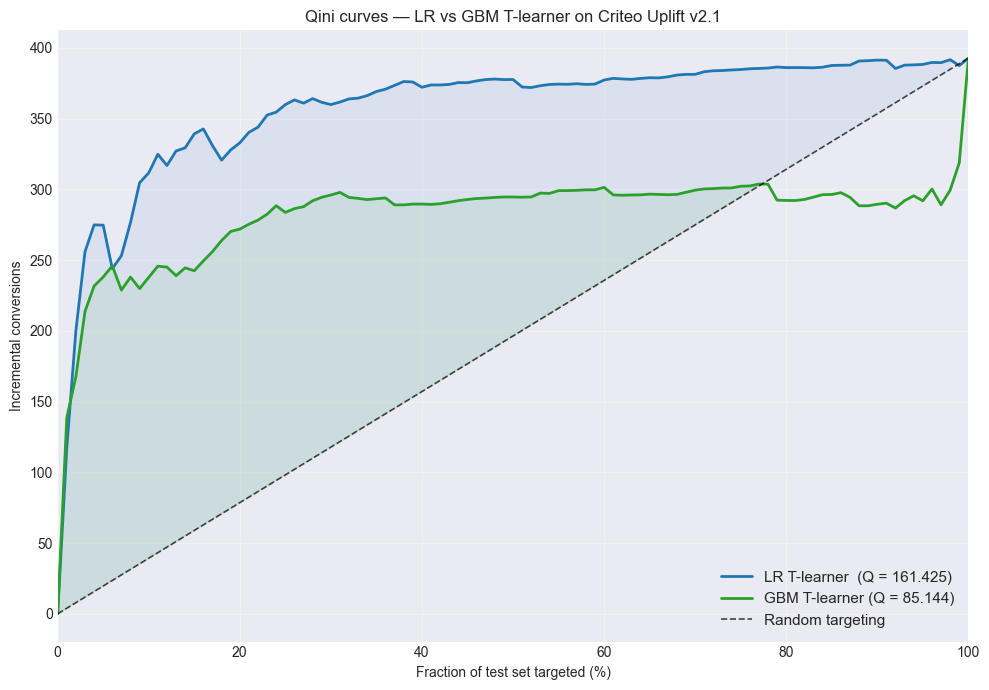

In [19]:
fig, ax = plt.subplots(figsize=(10, 7))

# Both Qini curves
ax.plot(k_pct * 100, qini_curve_lr,  color="#1f77b4", linewidth=2.0,
        label=f"LR T-learner  (Q = {q_lr:.3f})")
ax.plot(k_pct * 100, qini_curve_gbm, color="#2ca02c", linewidth=2.0,
        label=f"GBM T-learner (Q = {q_gbm:.3f})")

# Shared random baseline (both reach roughly the same K=100% incremental value
# since both predict on the same test set; use either curve's baseline)
ax.plot(k_pct * 100, baseline_gbm, color="black", linewidth=1.2,
        linestyle="--", alpha=0.7, label="Random targeting")

# Light shading on the model gains over random
ax.fill_between(k_pct * 100, baseline_gbm, qini_curve_gbm,
                where=(qini_curve_gbm >= baseline_gbm),
                color="#2ca02c", alpha=0.08)
ax.fill_between(k_pct * 100, baseline_lr, qini_curve_lr,
                where=(qini_curve_lr >= baseline_lr),
                color="#1f77b4", alpha=0.08)

ax.set_xlabel("Fraction of test set targeted (%)")
ax.set_ylabel("Incremental conversions")
ax.set_title("Qini curves — LR vs GBM T-learner on Criteo Uplift v2.1")
ax.legend(loc="lower right", fontsize=11)
ax.set_xlim(0, 100)
ax.grid(True, alpha=0.3)

plt.tight_layout()
out_path = FIG_DIR / "qini_curves_comparison.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved {out_path}")
plt.show()